# BCB - Banco Central do Brasil

Visualização dos indicadores do Banco Central: taxa SELIC, câmbio USD/BRL, IGP-M, dívida pública, balança comercial e IBC-Br.

**Fonte:** Banco Central do Brasil - Sistema Gerenciador de Séries Temporais (SGS)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

DATA_DIR = '../data/bcb'
CUTOFF = '2021-03-01'

In [2]:
# Carregar dados
daily = pd.read_csv(os.path.join(DATA_DIR, 'daily.csv'), index_col=0, parse_dates=True)
monthly = pd.read_csv(os.path.join(DATA_DIR, 'monthly.csv'), index_col=0, parse_dates=True)

with open(os.path.join(DATA_DIR, 'daily.dictionary.json'), encoding='utf-8') as f:
    daily_dict = json.load(f)
with open(os.path.join(DATA_DIR, 'monthly.dictionary.json'), encoding='utf-8') as f:
    monthly_dict = json.load(f)

daily = daily[daily.index >= CUTOFF]
monthly = monthly[monthly.index >= CUTOFF]

print(f'Diário: {daily.shape} | {daily.index.min().date()} a {daily.index.max().date()}')
print(f'Mensal: {monthly.shape} | {monthly.index.min().date()} a {monthly.index.max().date()}')
print(f'Colunas diárias: {list(daily.columns)}')
print(f'Colunas mensais: {list(monthly.columns)}')

Daily: (1886, 4) | 2021-03-01 to 2026-04-29
Monthly: (60, 4) | 2021-03-01 to 2026-02-01
Daily columns: ['selic_meta', 'selic_diaria', 'cambio_venda', 'cambio_compra']
Monthly columns: ['igpm', 'divida_liquida_pib', 'balanca_comercial', 'ibc_br']


## Taxa SELIC - Meta e Efetiva Diária
Taxa básica de juros da economia brasileira, definida pelo COPOM.

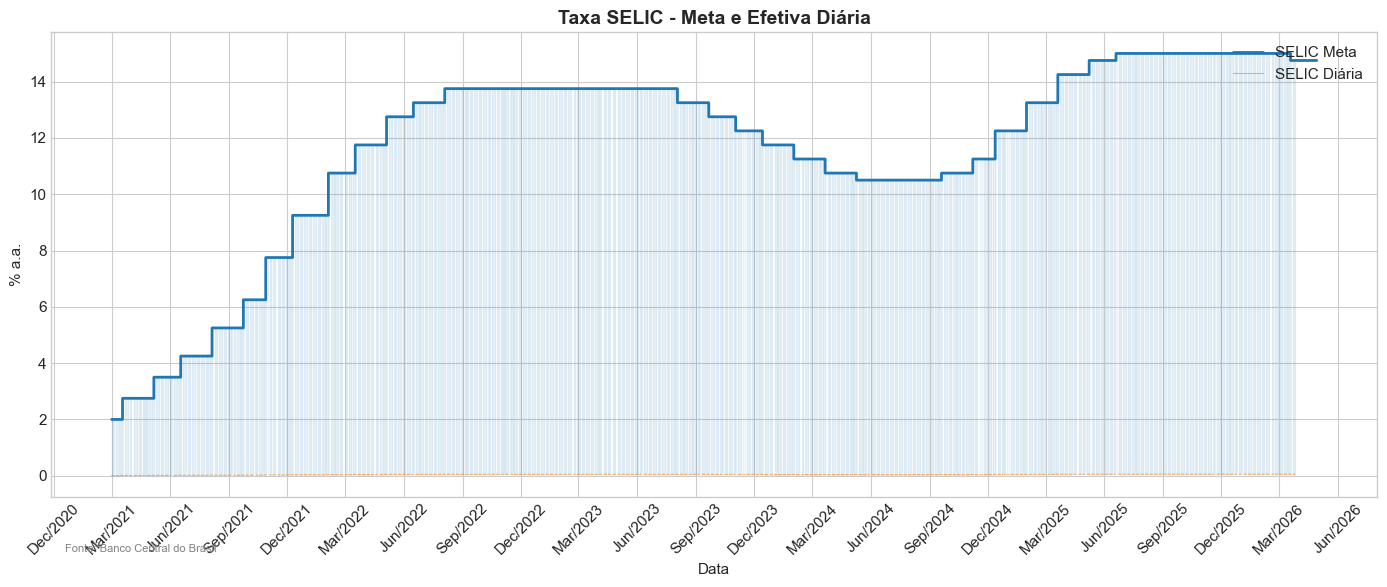

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.step(daily.index, daily['selic_meta'], where='post', label='SELIC Meta', color='#1f77b4', linewidth=2)
ax.plot(daily.index, daily['selic_diaria'], label='SELIC Diária', color='#ff7f0e', alpha=0.6, linewidth=0.8)
ax.fill_between(daily.index, daily['selic_meta'], daily['selic_diaria'], alpha=0.1, color='#1f77b4')

ax.set_title('Taxa SELIC - Meta e Efetiva Diária', fontsize=14, fontweight='bold')
ax.set_ylabel('% a.a.')
ax.set_xlabel('Data')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: Banco Central do Brasil', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Câmbio USD/BRL - Compra e Venda
Taxa de câmbio comercial dólar americano.

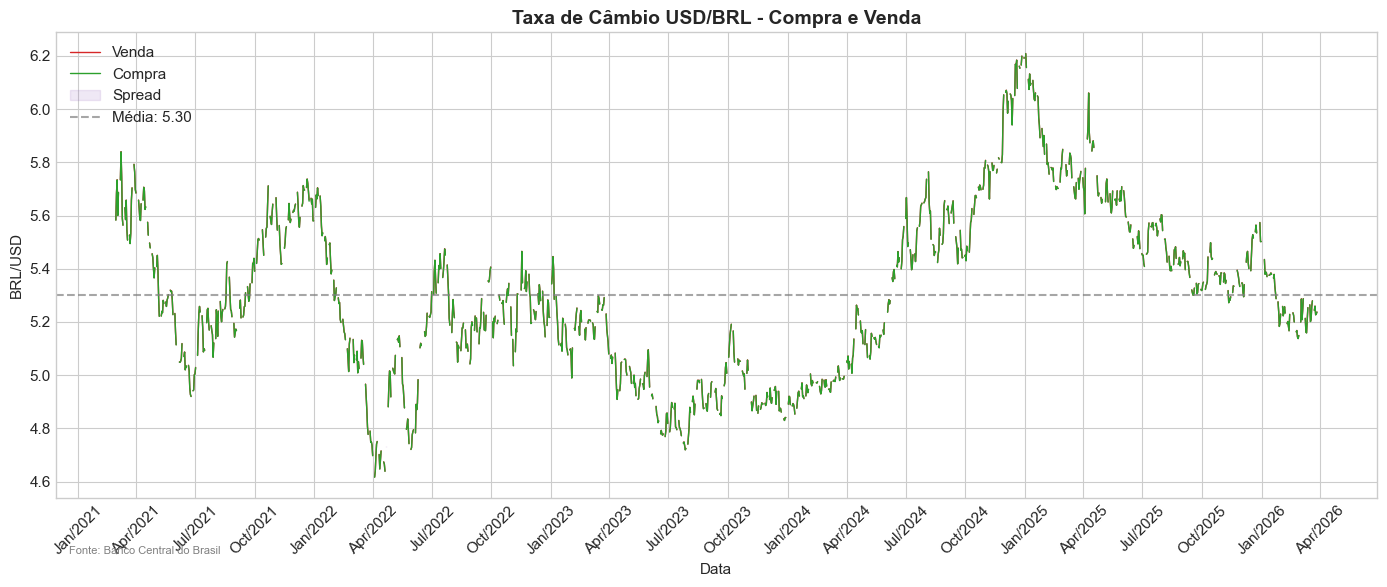

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(daily.index, daily['cambio_venda'], label='Venda', color='#d62728', linewidth=1)
ax.plot(daily.index, daily['cambio_compra'], label='Compra', color='#2ca02c', linewidth=1)
ax.fill_between(daily.index, daily['cambio_compra'], daily['cambio_venda'], alpha=0.15, color='#9467bd', label='Spread')

mean_val = daily['cambio_venda'].mean()
ax.axhline(y=mean_val, color='gray', linestyle='--', alpha=0.7, label=f'Média: {mean_val:.2f}')

ax.set_title('Taxa de Câmbio USD/BRL - Compra e Venda', fontsize=14, fontweight='bold')
ax.set_ylabel('BRL/USD')
ax.set_xlabel('Data')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: Banco Central do Brasil', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## IGP-M - Variação Mensal
Índice Geral de Preços - Mercado, calculado pela FGV.

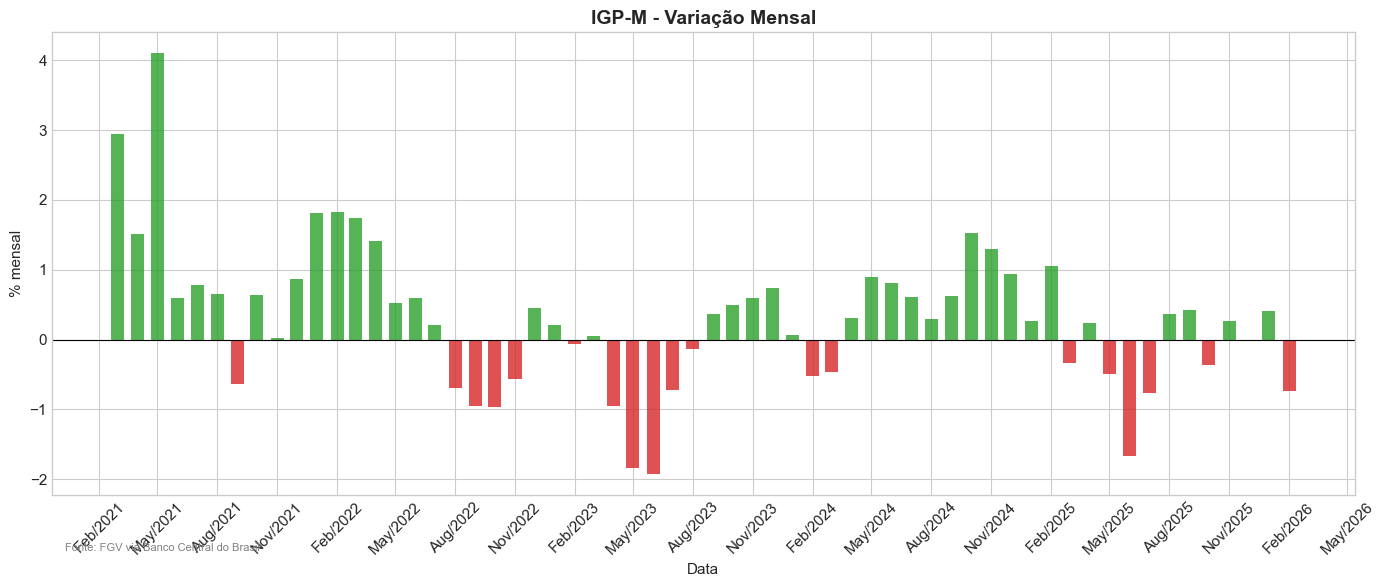

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#2ca02c' if v >= 0 else '#d62728' for v in monthly['igpm']]
ax.bar(monthly.index, monthly['igpm'], width=20, color=colors, alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_title('IGP-M - Variação Mensal', fontsize=14, fontweight='bold')
ax.set_ylabel('% mensal')
ax.set_xlabel('Data')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: FGV via Banco Central do Brasil', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Dívida Líquida do Setor Público (% do PIB)
Proporção da dívida líquida do setor público consolidado em relação ao PIB.

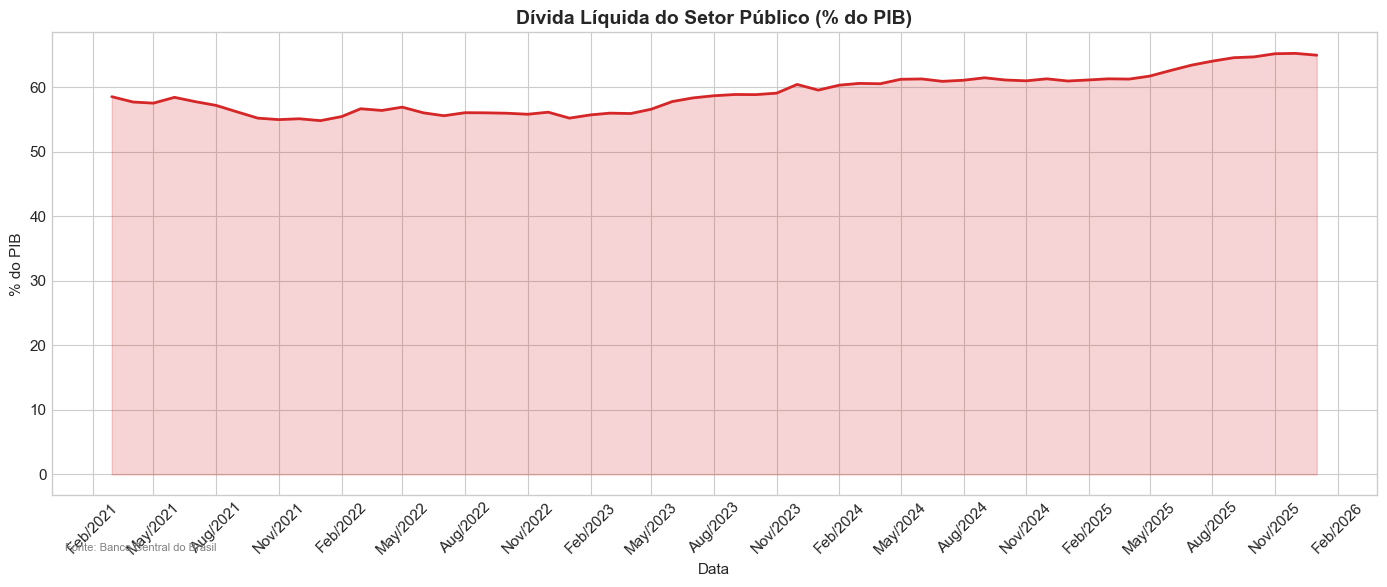

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly.index, monthly['divida_liquida_pib'], color='#d62728', linewidth=2)
ax.fill_between(monthly.index, monthly['divida_liquida_pib'], alpha=0.2, color='#d62728')

ax.set_title('Dívida Líquida do Setor Público (% do PIB)', fontsize=14, fontweight='bold')
ax.set_ylabel('% do PIB')
ax.set_xlabel('Data')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: Banco Central do Brasil', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Balança Comercial - Saldo Mensal
Saldo da balança comercial (exportações - importações).

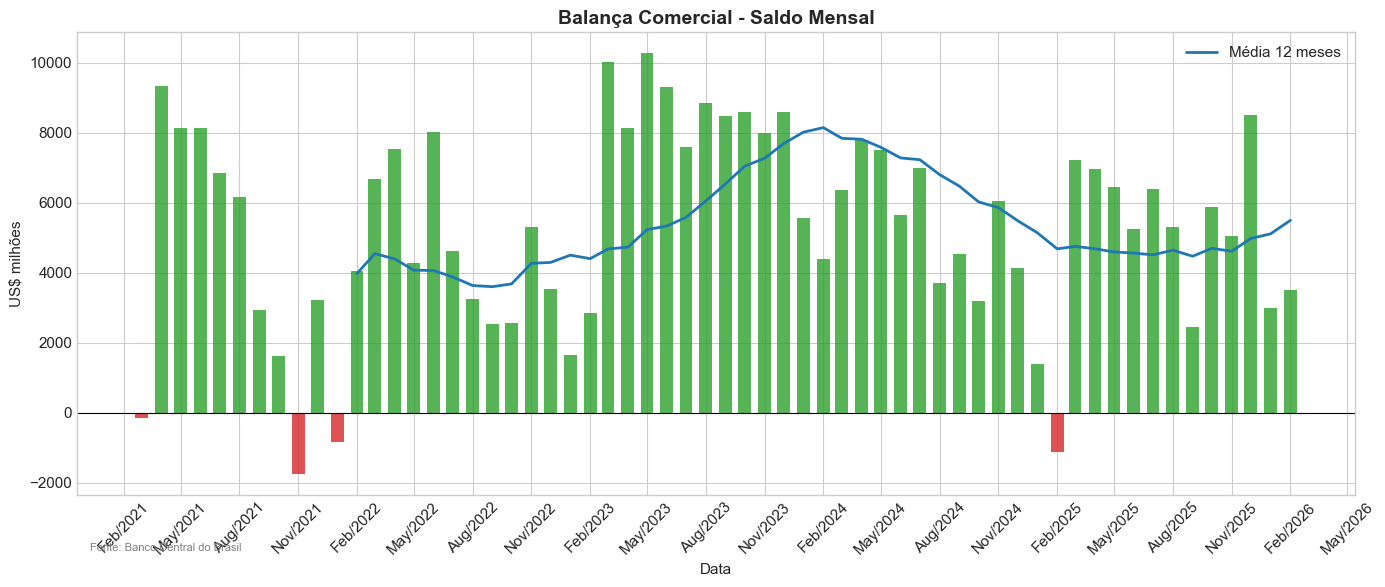

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#2ca02c' if v >= 0 else '#d62728' for v in monthly['balanca_comercial']]
ax.bar(monthly.index, monthly['balanca_comercial'], width=20, color=colors, alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)

# Média móvel 12 meses
rolling = monthly['balanca_comercial'].rolling(12).mean()
ax.plot(monthly.index, rolling, color='#1f77b4', linewidth=2, label='Média 12 meses')

ax.set_title('Balança Comercial - Saldo Mensal', fontsize=14, fontweight='bold')
ax.set_ylabel('US$ milhões')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: Banco Central do Brasil', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## IBC-Br - Índice de Atividade Econômica
Proxy mensal do PIB calculado pelo Banco Central.

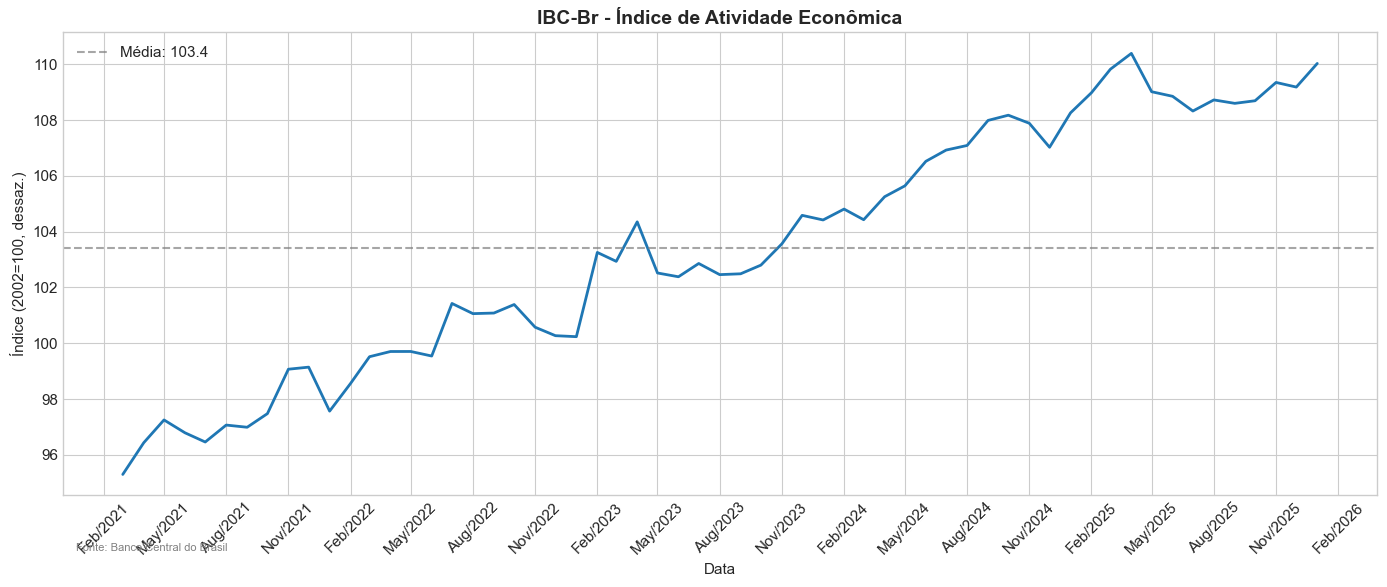

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly.index, monthly['ibc_br'], color='#1f77b4', linewidth=2)
mean_ibc = monthly['ibc_br'].mean()
ax.axhline(y=mean_ibc, color='gray', linestyle='--', alpha=0.7, label=f'Média: {mean_ibc:.1f}')

ax.set_title('IBC-Br - Índice de Atividade Econômica', fontsize=14, fontweight='bold')
ax.set_ylabel('Índice (2002=100, dessaz.)')
ax.set_xlabel('Data')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.annotate('Fonte: Banco Central do Brasil', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## Dashboard - Visão Geral BCB

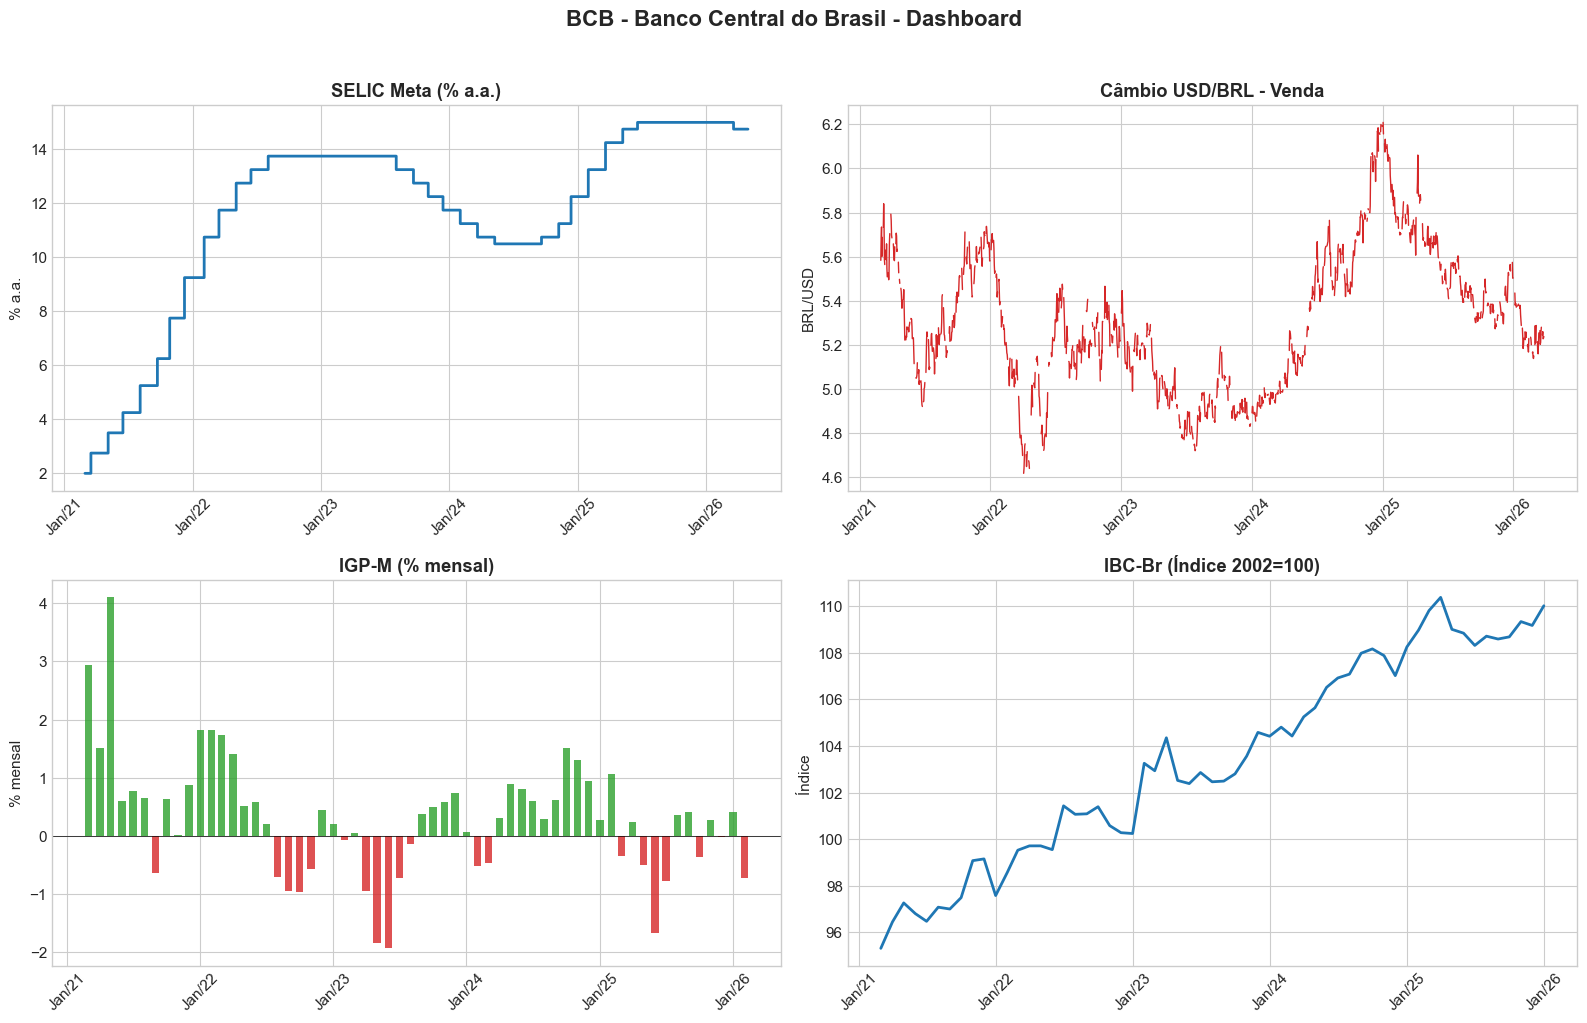

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# SELIC Meta (taxa alvo)
ax = axes[0, 0]
ax.step(daily.index, daily['selic_meta'], where='post', color='#1f77b4', linewidth=2)
ax.set_title('SELIC Meta (% a.a.)', fontweight='bold')
ax.set_ylabel('% a.a.')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# Câmbio
ax = axes[0, 1]
ax.plot(daily.index, daily['cambio_venda'], color='#d62728', linewidth=1)
ax.set_title('Câmbio USD/BRL - Venda', fontweight='bold')
ax.set_ylabel('BRL/USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# IGP-M
ax = axes[1, 0]
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in monthly['igpm']]
ax.bar(monthly.index, monthly['igpm'], width=20, color=colors, alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('IGP-M (% mensal)', fontweight='bold')
ax.set_ylabel('% mensal')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

# IBC-Br
ax = axes[1, 1]
ax.plot(monthly.index, monthly['ibc_br'], color='#1f77b4', linewidth=2)
ax.set_title('IBC-Br (Índice 2002=100)', fontweight='bold')
ax.set_ylabel('Índice')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.tick_params(axis='x', rotation=45)

fig.suptitle('BCB - Banco Central do Brasil - Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()